<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 2: PipelineTokenizacionNormalizaciónStemmerLematizacion</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Crear una clase con un pipeline que tokenice, elimine stopwords, aplique stemming y lematizacion, y mida el impacto en el vocabulario.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Crea tu propia clase para preprocesamiento de texto considerando Normalización de texto, Stemming/Lematización y Tokenización para un corpus en inglés y español</li>
<li>Procesa el corpus provisto de 4 textos en inglés y procesa el corpus de noticias en español</li>
<li>Calcula la reduccion de vocabulario en cada etapa</li>
<li>Visualiza los resultados con matplotlib</li>

</ul>
</div>

In [195]:
import nltk
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer,LancasterStemmer
from nltk.corpus import wordnet
from nltk.corpus import stopwords
import string 
import unicodedata
import pandas as pd
import re
from typing import Any, Set, Optional, List, Tuple
import spacy
from collections import Counter
nltk.download('wordnet')
nltk.download('omw-1.4')
nlp_es = spacy.load("es_core_news_sm")

class NLPTextCleaningPipeline:

    _URL_PATTERN = re.compile(r'https?://[^\s]+\.?[^\s]*')
    _EMAIL_PATTERN = re.compile(r'[\w.]+@[\w.]+\.[a-zA-Z]{2,}')
    _MENTION_PATTERN = re.compile(r'@\w+')
    _HASHTAG_PATTERN = re.compile(r'#\w+')
    _NUMBER_PATTERN = re.compile(r'\S*\d\S*')
    _EMOJI_PATTERN = re.compile(r'[^\x00-\x7Fáéíóúüñ¡¿ÁÉÍÓÚÜÑa-zA-Z \n.,!?]')
    _PUNCTUATION_PATTERN = re.compile(r'[^\w\sáéíóúüñÁÉÍÓÚÜÑ]', re.UNICODE)
    _SPACE_PATTERN = re.compile(r'\s+')

    DEFAULT_OPTIONS = {"urls", "correos", "menciones", "hashtags",
                      "numeros", "emojis", "puntuacion", "espacios"}
    DEFAULT_OPTIONS_STEAM = {"Porter", "Snowball", "Lancaster"}
    
    def __init__(self, 
                 idioma: str = 'spanish',
                 opciones_normalizar: Set[str] = None,#{"urls", "correos", "menciones", "hashtags", "numeros", "emojis", "puntuacion", "espacios"},
                 remover_acentos: bool = True,
                 remover_stopwords: bool = True,
                 normalizar_unicode: bool = True,
                 metodo_stem: Optional[str] = None):
        
        self.idioma = idioma
        self.stopswords = set(stopwords.words('spanish' if idioma=='spanish' else 'english'))
        self.lematizer = WordNetLemmatizer()
        self.metodo_stem = metodo_stem
        
        self.opciones_a_normalizar = opciones_normalizar or self.DEFAULT_OPTIONS

        self.remover_acentos = remover_acentos
        self.remover_stopwords = remover_stopwords
        self.normalizar_unicode = normalizar_unicode

        self._operaciones = {
            'urls': self._limpiar_urls,
            'correos': self._limpiar_emails,
            'menciones': self._limpiar_menciones,
            'hashtags': self._limpiar_hashtags,
            'numeros': self._limpiar_numeros,
            'emojis': self._limpiar_emojis,
            'puntuacion': self._limpiar_puntuacion,
            'espacios': self._normalizar_espacios
        }
    
    #------------Funciones de limpieza---------------------------------------------------------
    def _limpiar_urls(self, parTexto: str) -> str:
        return self._URL_PATTERN.sub('', parTexto)
    
    def _limpiar_emails(self, parTexto: str) -> str:
        return self._EMAIL_PATTERN.sub('', parTexto)
    
    def _limpiar_menciones(self, parTexto: str) -> str:
        return self._MENTION_PATTERN.sub('', parTexto)
    
    def _limpiar_hashtags(self, parTexto: str) -> str:
        return self._HASHTAG_PATTERN.sub('', parTexto)
    
    def _limpiar_numeros(self, parTexto: str) -> str:
        return self._NUMBER_PATTERN.sub('', parTexto)
    
    def _limpiar_emojis(self, parTexto: str) -> str:
        return self._EMOJI_PATTERN.sub('', parTexto)
    
    def _limpiar_puntuacion(self, parTexto: str) -> str:
        return self._PUNCTUATION_PATTERN.sub(' ', parTexto)
    
    def _normalizar_espacios(self, parTexto: str) -> str:
        return self._SPACE_PATTERN.sub(' ', parTexto).strip()
    
    
    #------------Tokenizacion---------------------------------------------------------
    def Tokenizar_Regex(self, parTexto: str) -> list:
        return re.findall(r"\b\w+\b", parTexto, re.UNICODE)

    def Tokenizar_Oraciones_NLTK(self, parTexto: str) -> list:
        return sent_tokenize(parTexto, language=self.idioma)
    
    def Tokenizar_Oraciones(self, parTexto: str) -> list:
        """Divide texto en oraciones usando regex."""
        patron = r'(?<=[.!?¿¡])\s+(?=[A-ZÁÉÍÓÚ])|(?<=[.!?])\s*$'
        oraciones = re.split(patron, parTexto.strip())
        return [s.strip() for s in oraciones if s.strip()]

    def Tokenizar_Palabras_NLTK(self, parTexto: str) -> list:
        return word_tokenize(parTexto, language=self.idioma)

#------------Stemming y Lematizacion---------------------------------------------------------
    def stemmeing(self, parTexto: str) :
        para_stemming = self.preprocesar(parTexto)
        stemMetodo = None
         # Español: forzar SnowballStemmer, las otras dos no soportan español
        if self.idioma.lower() == 'spanish':
            stemMetodo = SnowballStemmer('spanish')
        
        # Ingles
        elif self.idioma.lower() == 'english':
            match self.metodo_stem:
                case "Porter":
                    stemMetodo = PorterStemmer()
                case "Snowball":
                    stemMetodo = SnowballStemmer(self.idioma)
                case "Lancaster":
                    stemMetodo = LancasterStemmer()
                case _:
                    stemMetodo = SnowballStemmer(self.idioma) # default a Snowball si no se especifica o no se reconoce el método
        
        else:
            stemMetodo = SnowballStemmer('english') #default a Snowball para otros idiomas si están soportados
        
        if stemMetodo:
            tokens = self.Tokenizar_Palabras_NLTK(para_stemming)
            return [stemMetodo.stem(token) for token in tokens]
        else: return None

    def graficar_stemming(self, vocabularios: list[dict], parTitulo:str):
        metodos = [item['Metodo'] for item in vocabularios]
        zise = [item['Vocabulario'] for item in vocabularios]
        colores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3A9F6A']
        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.bar(metodos, zise, color=colores[:len(metodos)], width=0.6)
        ax.bar_label(bars, fontsize=11, fontweight='bold')
        if 'Original' in metodos:
            original_idx = metodos.index('Original')
            original = zise[original_idx]
            for i, metodo in enumerate(metodos):
                if metodo != 'Original':
                    reduccion = ((original - zise[i]) / original) * 100
                    ax.text(i, zise[i] + 1, f'-{reduccion:.1f}%', 
                        ha='center', fontsize=10, fontweight='bold')
    
        ax.set_title(parTitulo, fontsize=13, fontweight='bold')
        ax.set_ylabel('Número de palabras únicas', fontsize=11)
        ax.set_xlabel('Método', fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()




    def lematizacion(self, parTexto: str):
        para_lematizacion = self.preprocesar(parTexto)
        lemmatizer  = None
         # Español: para español se puede usar WordNetLemmatizer pero no es tan
        if self.idioma.lower() == 'english':
            lemmatizer  = WordNetLemmatizer()
        elif self.idioma.lower() == 'spanish':
            doc = nlp_es(para_lematizacion)
            lemas = []
            for token in doc:
                if not token.is_punct and not token.is_space:
                    lemas.append(token.lemma_)
        
            return lemas
                    
        if lemmatizer :
            tokens = self.Tokenizar_Palabras_NLTK(para_lematizacion)
            return [lemmatizer .lemmatize(token) for token in tokens]
        else: return None


    def normalizar(self, parTexto: str) -> str:
        resultado = parTexto
        orden_operaciones = ['urls', 'correos', 'menciones', 'hashtags', 
                         'numeros', 'emojis', 'puntuacion', 'espacios']
        for opcion in orden_operaciones:
            if opcion in self.opciones_a_normalizar:
                match opcion:
                    case 'urls':
                        resultado = self._limpiar_urls(resultado)
                    case 'correos':
                        resultado = self._limpiar_emails(resultado)
                    case 'menciones':
                        resultado = self._limpiar_menciones(resultado)
                    case 'hashtags':
                        resultado = self._limpiar_hashtags(resultado)
                    case 'numeros':
                        resultado = self._limpiar_numeros(resultado)
                    case 'emojis':
                        resultado = self._limpiar_emojis(resultado)
                    case 'puntuacion':
                        resultado = self._limpiar_puntuacion(resultado)
                    case 'espacios':
                        resultado = self._normalizar_espacios(resultado)
                    case _:
                        pass
        
        return resultado.lower()

    def remover_acentosM(self, parTexto: str) -> str:
        """Elimina tildes y diacríticos usando normalización Unicode."""

        if not self.remover_acentos:
         return parTexto
    
        nfkd = unicodedata.normalize('NFKD', parTexto)
        return ''.join(c for c in nfkd if not unicodedata.combining(c))
    
    def remover_stopwordsM(self, parText:str) -> str:
        """Elimina stopwords de una lista de tokens."""
        if not self.remover_stopwords:
                    return parText      

        tokens = self.get_vocabulario(parText)
        if not self.remover_stopwords:
            return tokens
        return [token for token in tokens if token.lower() not in self.stopswords]
    
    def graficar_frecuencia(self, freq_con: List[tuple[Any, int]], freq_sin: List[tuple[Any, int]], parTitulo: str, top_n: int = 10):
        """
        Grafica la frecuencia de palabras con y sin stopwords
        
        Args:
            freq_con: Lista de tuplas (palabra, frecuencia) CON stopwords
            freq_sin: Lista de tuplas (palabra, frecuencia) SIN stopwords
            parTitulo: Título del gráfico
            top_n: Número de palabras más frecuentes a mostrar
        """
        fig, axes = plt.subplots(1, 2, figsize=(15, 10))
        sin_stopwords_freq = Counter(freq_sin).most_common(top_n)
        con_stopwords_freq = Counter(freq_con).most_common(top_n)
        for ax, data, titulo, color in [
            (axes[0], con_stopwords_freq, 'Con stopwords', 'slategray'),
            (axes[1], sin_stopwords_freq, 'Sin stopwords', 'steelblue')
        ]:
            words, counts = zip(*data)
            ax.barh(list(reversed(words)), list(reversed(counts)), color=color)
            ax.set_title(titulo, fontsize=11)
            ax.set_xlabel('Frecuencia')
        
        plt.suptitle(parTitulo, fontsize=12)
        plt.tight_layout()
        plt.show()
    

    def get_vocabulario(self, parTexto: str) -> Set[str]:
        """Devuelve el vocabulario único de un texto después de preprocesar."""
        texto_preprocesado = self.preprocesar(parTexto)
        tokens = self.Tokenizar_Palabras_NLTK(texto_preprocesado)
        return set(tokens)
    
    def preprocesar(self, parTexto: str) -> str:
       if not parTexto:
            return ""
       #1.- Normalizacion
       texto_normalizado = self.normalizar(parTexto)
       #2.- Quitar acentos
       texto_normalizado=self.remover_acentosM(texto_normalizado)

       return texto_normalizado

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\iscer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\iscer\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [120]:
# Corpus simple en inglés
corpus_en = [
    {'Documento':'text_1','texto':'Natural language processing systems are becoming increasingly sophisticated.'},
    {'Documento':'text_2','texto':'Deep learning models have revolutionized text classification and generation tasks.'},
    {'Documento':'text_3','texto':'Tokenization is the fundamental first step in any NLP preprocessing pipeline.'},
    {'Documento':'text_4','texto':'Researchers are studying computational approaches to human language understanding.'},
]
df_corpus_en = pd.DataFrame(corpus_en)
df_corpus_en

,Documento,texto
0,text_1,Natural language processing systems are becomi...
1,text_2,Deep learning models have revolutionized text ...
2,text_3,Tokenization is the fundamental first step in ...
3,text_4,Researchers are studying computational approac...


In [140]:
nlp_cleaning_eng = NLPTextCleaningPipeline(idioma = 'english')
print("="*10,"Preprocesamiento","="*50)
for index, row in df_corpus_en.iterrows():
    print("="*10,f"{row['Documento']}","="*50)
    print(f"Documento: {row['texto']}")
    print(f"Procesado: {nlp_cleaning_eng.preprocesar(row['texto'])}")
    print()




========== Preprocesamiento ==================================================
========== text_1 ==================================================
Documento: Natural language processing systems are becoming increasingly sophisticated.
Procesado: natural language processing systems are becoming increasingly sophisticated 

========== text_2 ==================================================
Documento: Deep learning models have revolutionized text classification and generation tasks.
Procesado: deep learning models have revolutionized text classification and generation tasks 

========== text_3 ==================================================
Documento: Tokenization is the fundamental first step in any NLP preprocessing pipeline.
Procesado: tokenization is the fundamental first step in any nlp preprocessing pipeline 

========== text_4 ==================================================
Documento: Researchers are studying computational approaches to human language understanding.
Proces

In [122]:
print("="*10,"Stemming","="*50)
dic_result = []
for index, row in df_corpus_en.iterrows():
    dic_stemming = []
    print("="*10,f"{row['Documento']}","="*50)
    print(f"Original: {row['texto']}")
    dic_stemming.append({'Metodo': 'Original','Vocabulario': len(set(nlp_cleaning_eng.Tokenizar_Palabras_NLTK(row['texto'])))})

    nlp_cleaning_eng.metodo_stem = "Porter"
    print(f"Stemming con Porter: {nlp_cleaning_eng.stemmeing(row['texto'])}")
    dic_stemming.append({'Metodo': 'Porter', 'Vocabulario': len(set(nlp_cleaning_eng.stemmeing(row['texto'])))})

    nlp_cleaning_eng.metodo_stem = "Snowball"
    print(f"Stemming con Snowball: {nlp_cleaning_eng.stemmeing(row['texto'])}")
    dic_stemming.append({'Metodo': 'Snowball', 'Vocabulario': len(set(nlp_cleaning_eng.stemmeing(row['texto'])))})

    nlp_cleaning_eng.metodo_stem = "Lancaster"
    print(f"Stemming con Lancaster: {nlp_cleaning_eng.stemmeing(row['texto'])}")
    dic_stemming.append({'Metodo': 'Lancaster', 'Vocabulario': len(set(nlp_cleaning_eng.stemmeing(row['texto'])))})
    print()
    dic_result.append({'Documento': row['Documento'], 'Stemming': dic_stemming})
    

========== Stemming ==================================================
========== text_1 ==================================================
Original: Natural language processing systems are becoming increasingly sophisticated.
Stemming con Porter: ['natur', 'languag', 'process', 'system', 'are', 'becom', 'increasingli', 'sophist']
Stemming con Snowball: ['natur', 'languag', 'process', 'system', 'are', 'becom', 'increas', 'sophist']
Stemming con Lancaster: ['nat', 'langu', 'process', 'system', 'ar', 'becom', 'increas', 'soph']

========== text_2 ==================================================
Original: Deep learning models have revolutionized text classification and generation tasks.
Stemming con Porter: ['deep', 'learn', 'model', 'have', 'revolution', 'text', 'classif', 'and', 'gener', 'task']
Stemming con Snowball: ['deep', 'learn', 'model', 'have', 'revolution', 'text', 'classif', 'and', 'generat', 'task']
Stemming con Lancaster: ['deep', 'learn', 'model', 'hav', 'revolv', 'text',

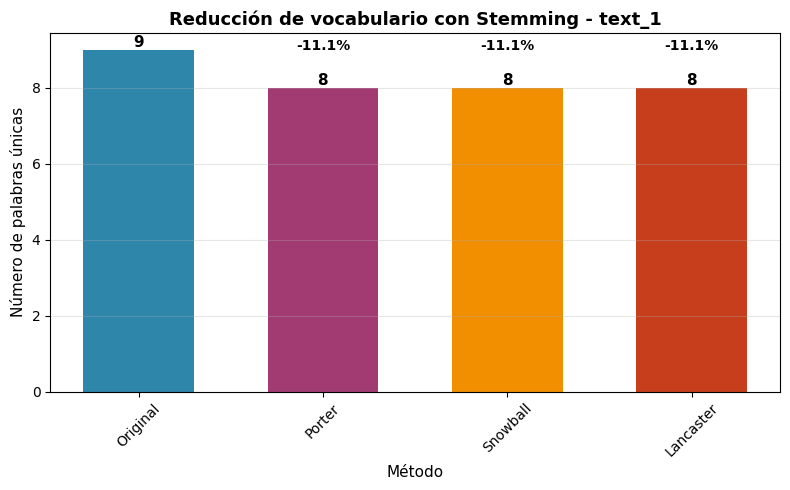

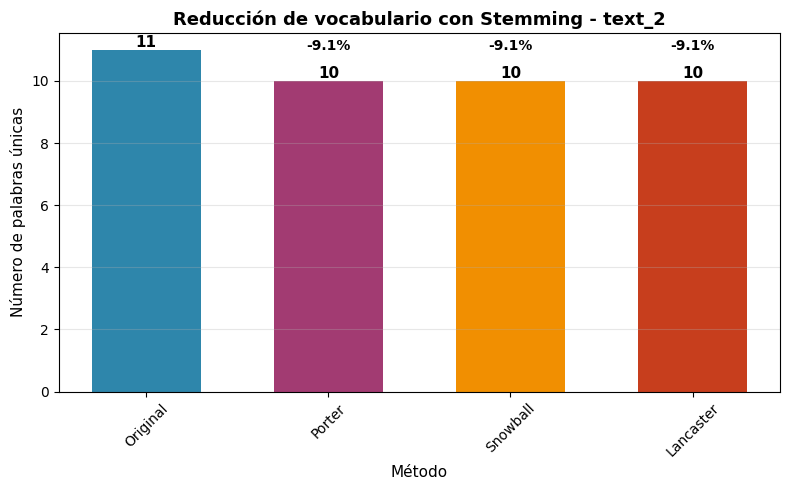

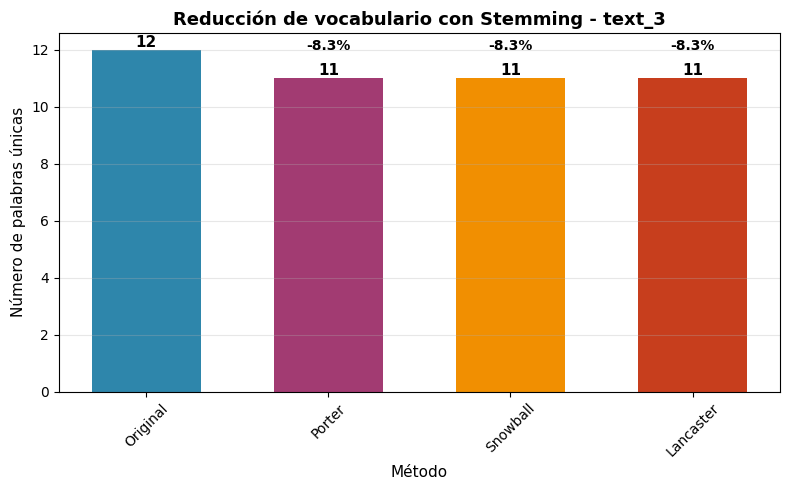

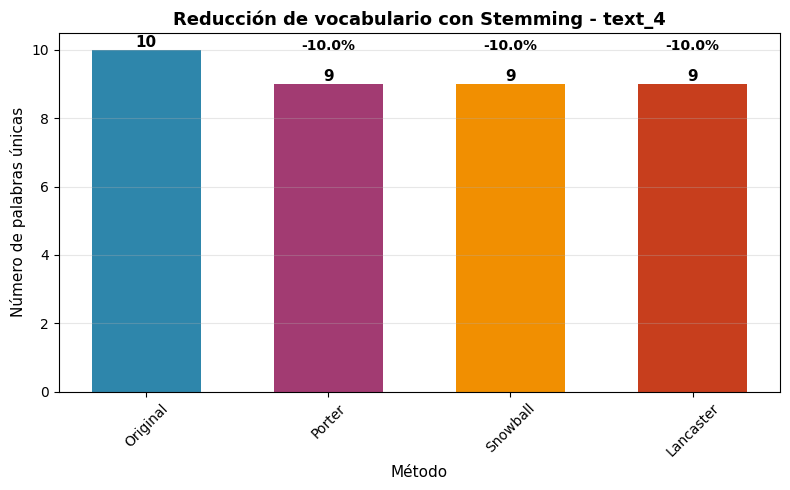

In [123]:
for item in dic_result:
    nlp_cleaning_eng.graficar_stemming(item['Stemming'], f"Reducción de vocabulario con Stemming - {item['Documento']}")




In [193]:
print("="*10,"lematizacion","="*50)
for index, row in df_corpus_en.iterrows():
    print("="*10,f"{row['Documento']}","="*50)
    text = nlp_cleaning_eng.preprocesar(row['texto'])
    print(f"Original: {nlp_cleaning_eng.Tokenizar_Palabras_NLTK(text)}")
    print(f"Lematizacion: {nlp_cleaning_eng.lematizacion(text)}")

    print()

========== lematizacion ==================================================
========== text_1 ==================================================
Original: ['natural', 'language', 'processing', 'systems', 'are', 'becoming', 'increasingly', 'sophisticated']
Lematizacion: ['natural', 'language', 'processing', 'system', 'are', 'becoming', 'increasingly', 'sophisticated']

========== text_2 ==================================================
Original: ['deep', 'learning', 'models', 'have', 'revolutionized', 'text', 'classification', 'and', 'generation', 'tasks']
Lematizacion: ['deep', 'learning', 'model', 'have', 'revolutionized', 'text', 'classification', 'and', 'generation', 'task']

========== text_3 ==================================================
Original: ['tokenization', 'is', 'the', 'fundamental', 'first', 'step', 'in', 'any', 'nlp', 'preprocessing', 'pipeline']
Lematizacion: ['tokenization', 'is', 'the', 'fundamental', 'first', 'step', 'in', 'any', 'nlp', 'preprocessing', 'pipeline

========== Stopwords ==================================================
Sin stopwords: [('computational', 1), ('natural', 1), ('learning', 1), ('models', 1), ('classification', 1), ('understanding', 1), ('sophisticated', 1), ('tokenization', 1), ('pipeline', 1), ('researchers', 1), ('tasks', 1), ('fundamental', 1), ('becoming', 1), ('studying', 1), ('deep', 1), ('processing', 1), ('human', 1), ('generation', 1), ('nlp', 1), ('first', 1), ('language', 1), ('systems', 1), ('step', 1), ('approaches', 1), ('increasingly', 1), ('preprocessing', 1), ('text', 1), ('revolutionized', 1)]
Con stopwords: [('language', 2), ('are', 2), ('natural', 1), ('processing', 1), ('systems', 1), ('becoming', 1), ('increasingly', 1), ('sophisticated', 1), ('deep', 1), ('learning', 1), ('models', 1), ('have', 1), ('revolutionized', 1), ('text', 1), ('classification', 1), ('and', 1), ('generation', 1), ('tasks', 1), ('tokenization', 1), ('is', 1), ('the', 1), ('fundamental', 1), ('first', 1), ('step', 1), ('in'

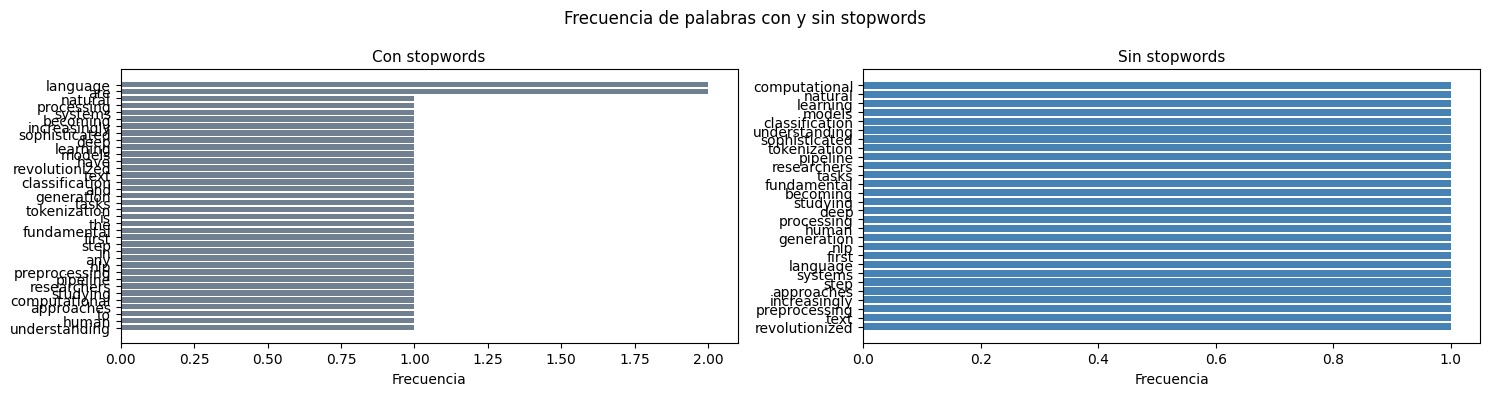

In [145]:
print("="*10,"Stopwords","="*50)
texto = ""
for index, row in df_corpus_en.iterrows():
    texto+= row['texto'] + " "

textoProcesado = nlp_cleaning_eng.preprocesar(texto)
sin_stopwords = nlp_cleaning_eng.remover_stopwordsM(textoProcesado)
con_stopwords = nlp_cleaning_eng.Tokenizar_Palabras_NLTK(textoProcesado)
sin_stopwords_freq = Counter(sin_stopwords).most_common()
con_stopwords_freq = Counter(con_stopwords).most_common()
print(f"Sin stopwords: {sin_stopwords_freq}")
print(f"Con stopwords: {con_stopwords_freq}")

nlp_cleaning_eng.graficar_frecuencia( con_stopwords,sin_stopwords, "Frecuencia de palabras con y sin stopwords",50)

In [175]:
#  Corpus de noticias en español
noticias = [
    {"categoria": "tecnología", "texto": "Apple presentó su nuevo chip M4 con IA integrada. La presentación fue en WWDC 2026 #Apple #M4"},
    {"categoria": "tecnología", "texto": "Google lanzó Gemini Ultra, su modelo más poderoso. Supera a GPT-4 en benchmarks https://blog.google.com"},
    {"categoria": "tecnología", "texto": "OpenAI anunció GPT-5 con capacidades multimodales avanzadas @OpenAI"},
    {"categoria": "economía",   "texto": "El peso mexicano se fortalece frente al dólar: $17.50 por USD en mercados internacionales"},
    {"categoria": "economía",   "texto": "La inflación en México cayó al 3.2% en abril 2026, según INEGI #Economia"},
    {"categoria": "economía",   "texto": "Inversión extranjera directa creció 15% en el primer trimestre del año"},
    {"categoria": "ciencia",    "texto": "Científicos descubrieron nueva especie de dinosaurio en Argentina #Paleontología"},
    {"categoria": "ciencia",    "texto": "Investigadores del MIT desarrollaron batería de estado sólido con carga en 5 minutos"},
    {"categoria": "ciencia",    "texto": "La NASA confirmó presencia de agua en la luna sur mediante misión Artemis https://nasa.gov"},
    {"categoria": "salud",      "texto": "Nuevo tratamiento contra el cáncer de páncreas muestra 80% de efectividad en ensayos clínicos"},
    {"categoria": "salud",      "texto": "OMS alerta sobre aumento de casos de resistencia a antibióticos en Latinoamérica #Salud"},
    {"categoria": "salud",      "texto": "Vacuna contra el dengue disponible en farmacias de México a partir de junio 2026"},
]

df_noticias_esp = pd.DataFrame(noticias)
df_noticias_esp

,categoria,texto
0,tecnología,Apple presentó su nuevo chip M4 con IA integra...
1,tecnología,"Google lanzó Gemini Ultra, su modelo más poder..."
2,tecnología,OpenAI anunció GPT-5 con capacidades multimoda...
3,economía,El peso mexicano se fortalece frente al dólar:...
4,economía,La inflación en México cayó al 3.2% en abril 2...
5,economía,Inversión extranjera directa creció 15% en el ...
6,ciencia,Científicos descubrieron nueva especie de dino...
7,ciencia,Investigadores del MIT desarrollaron batería d...
8,ciencia,La NASA confirmó presencia de agua en la luna ...
9,salud,Nuevo tratamiento contra el cáncer de páncreas...


In [187]:
nlp_cleaning_spanish = NLPTextCleaningPipeline(idioma = 'spanish')
print("="*10,"Preprocesamiento","="*50)
for index, row in df_noticias_esp.iterrows():
    print("="*10,f"{row['categoria']}","="*50)
    print(f"Texto: {row['texto']}")
    print(f"Procesado: {nlp_cleaning_spanish.preprocesar(row['texto'])}")
    print()

    


========== Preprocesamiento ==================================================
========== tecnología ==================================================
Texto: Apple presentó su nuevo chip M4 con IA integrada. La presentación fue en WWDC 2026 #Apple #M4
Procesado: apple presento su nuevo chip con ia integrada la presentacion fue en wwdc

========== tecnología ==================================================
Texto: Google lanzó Gemini Ultra, su modelo más poderoso. Supera a GPT-4 en benchmarks https://blog.google.com
Procesado: google lanzo gemini ultra su modelo mas poderoso supera a en benchmarks

========== tecnología ==================================================
Texto: OpenAI anunció GPT-5 con capacidades multimodales avanzadas @OpenAI
Procesado: openai anuncio con capacidades multimodales avanzadas

========== economía ==================================================
Texto: El peso mexicano se fortalece frente al dólar: $17.50 por USD en mercados internacionales
Procesado: 

In [178]:
print("="*10,"Stemming","="*50)
dic_result = []
for index, row in df_noticias_esp.iterrows():
    dic_stemming = []
    print("="*10,f"{row['categoria']}","="*50)
    print(f"Original: {row['texto']}")
    dic_stemming.append({'Metodo': 'Original','Vocabulario': len(set(nlp_cleaning_spanish.Tokenizar_Palabras_NLTK(row['texto'])))})

    nlp_cleaning_spanish.metodo_stem = "Snowball"
    print(f"Stemming con Snowball: {nlp_cleaning_spanish.stemmeing(row['texto'])}")
    dic_stemming.append({'Metodo': 'Snowball', 'Vocabulario': len(set(nlp_cleaning_spanish.stemmeing(row['texto'])))})

    print()
    dic_result.append({'Documento': row['categoria'], 'Stemming': dic_stemming})
    

========== Stemming ==================================================
========== tecnología ==================================================
Original: Apple presentó su nuevo chip M4 con IA integrada. La presentación fue en WWDC 2026 #Apple #M4
Stemming con Snowball: ['apple', 'present', 'su', 'nuev', 'chip', 'con', 'ia', 'integr', 'la', 'present', 'fue', 'en', 'wwdc']

========== tecnología ==================================================
Original: Google lanzó Gemini Ultra, su modelo más poderoso. Supera a GPT-4 en benchmarks https://blog.google.com
Stemming con Snowball: ['googl', 'lanz', 'gemini', 'ultra', 'su', 'model', 'mas', 'poder', 'super', 'a', 'en', 'benchmarks']

========== tecnología ==================================================
Original: OpenAI anunció GPT-5 con capacidades multimodales avanzadas @OpenAI
Stemming con Snowball: ['openai', 'anunci', 'con', 'capac', 'multimodal', 'avanz']

========== economía ==================================================
Origi

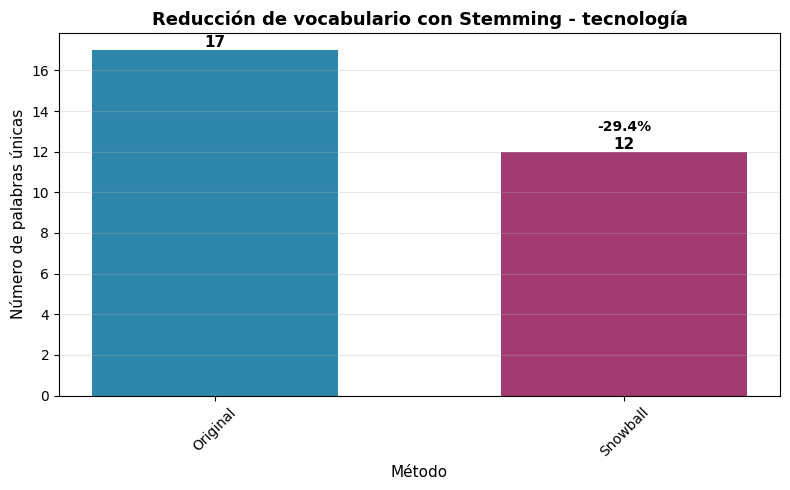

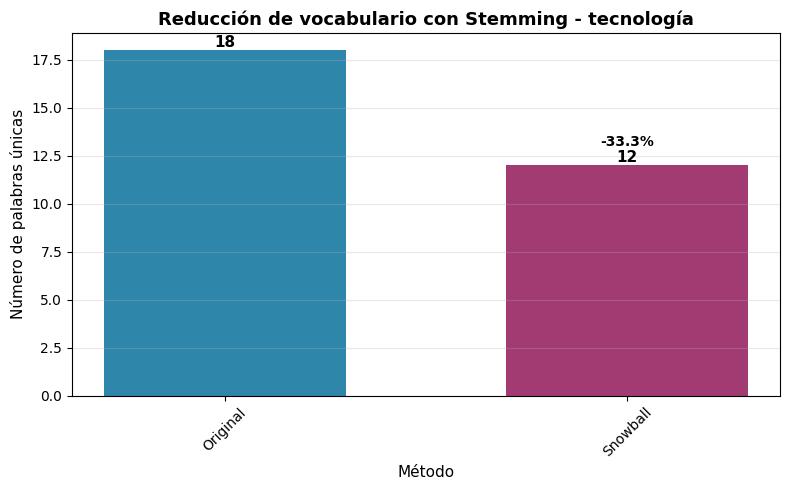

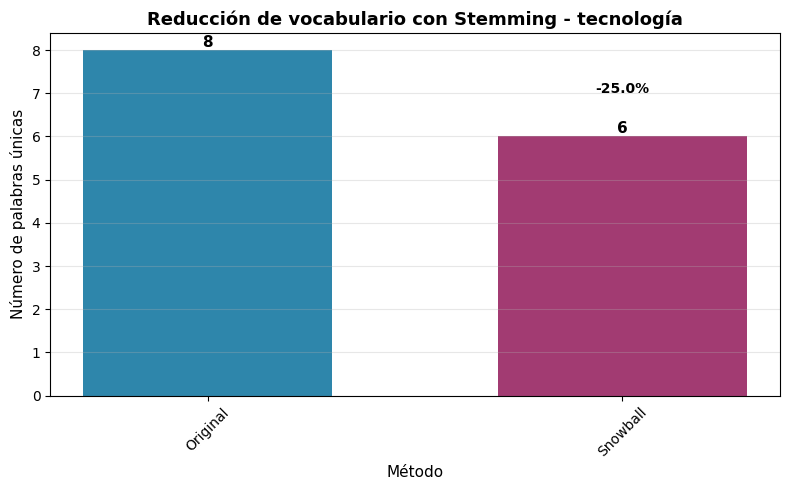

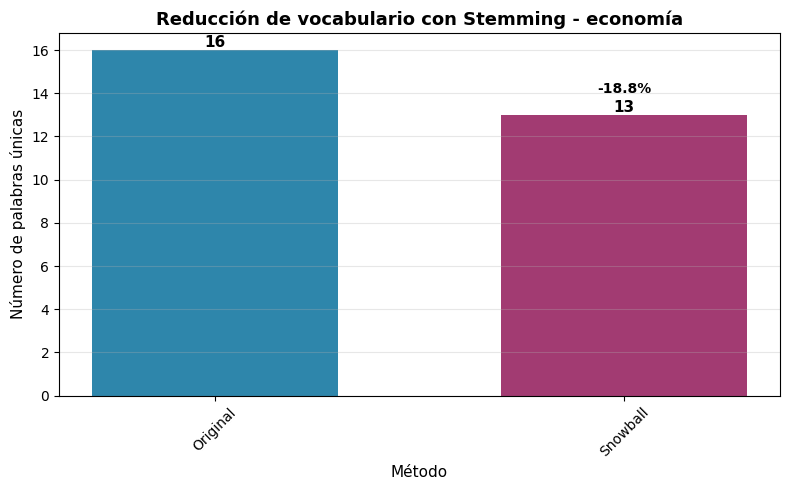

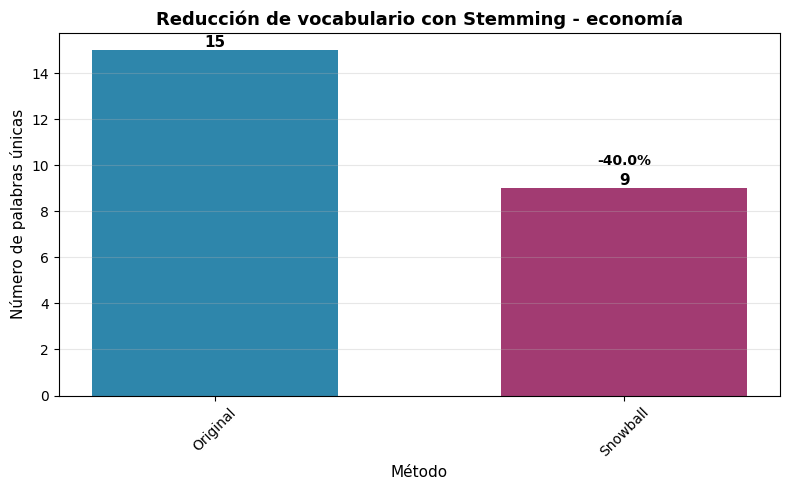

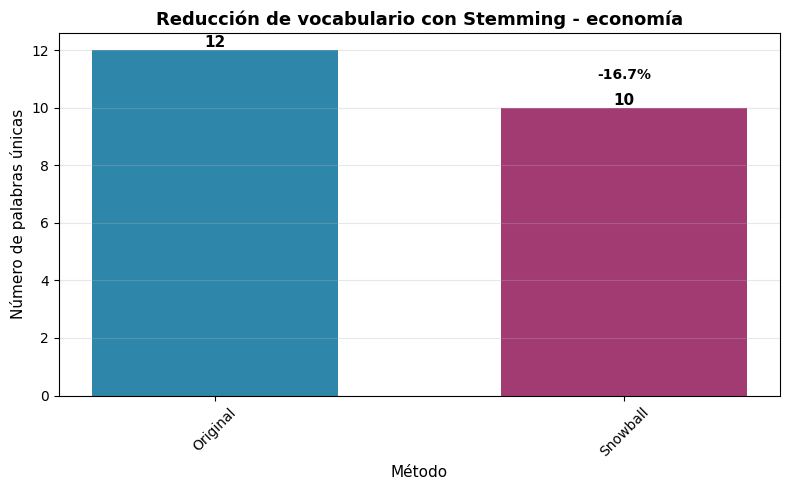

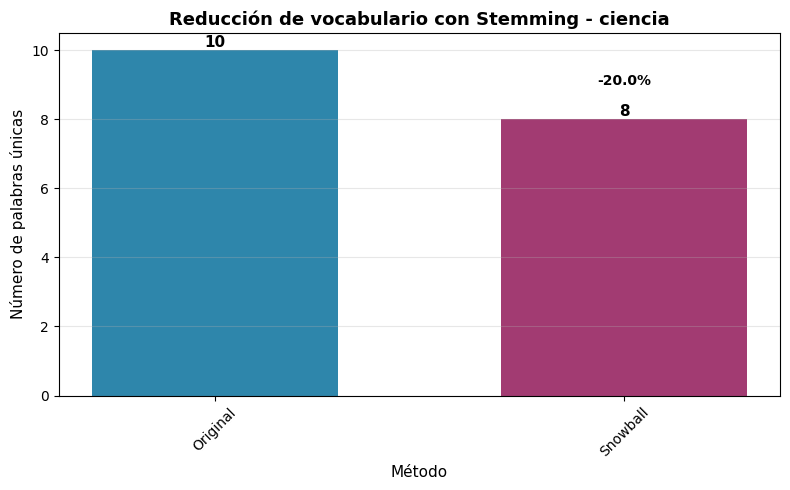

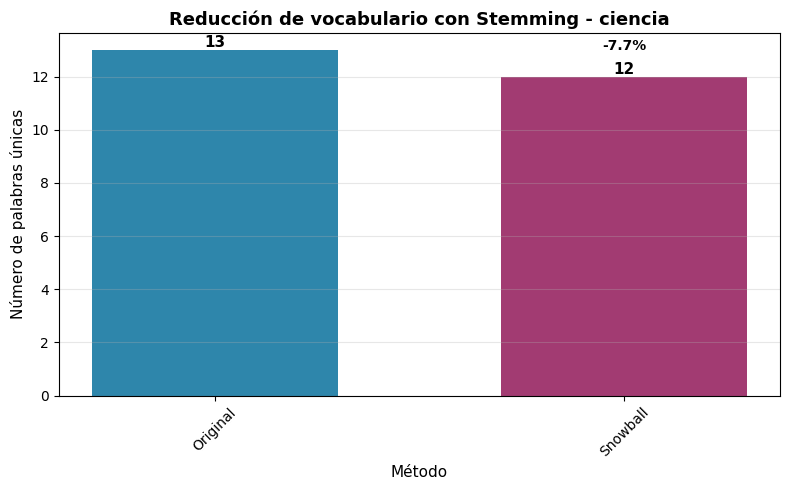

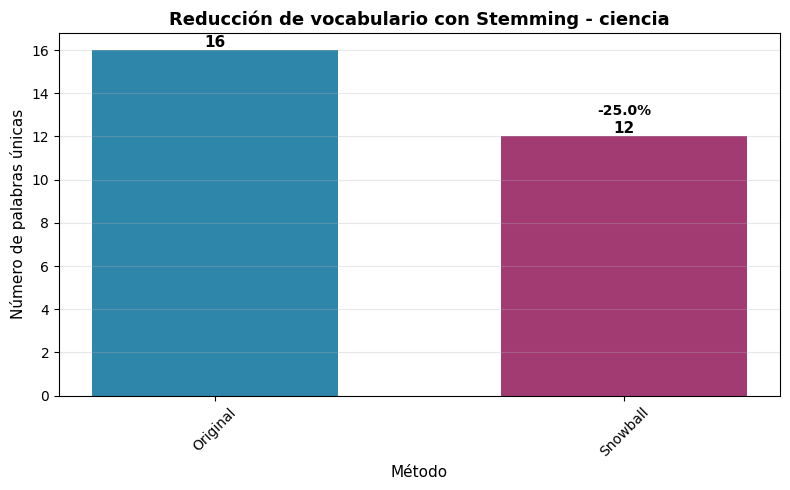

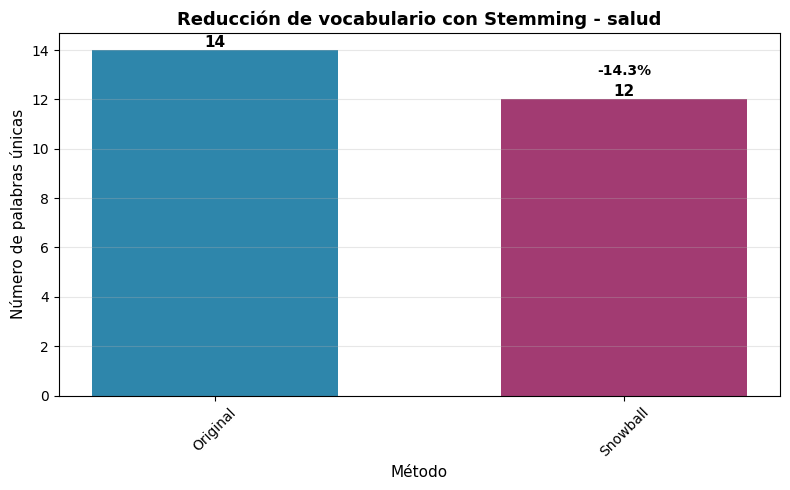

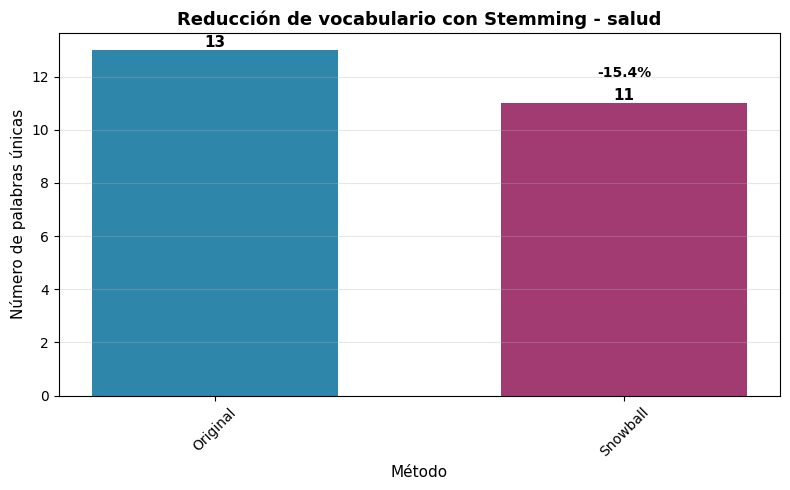

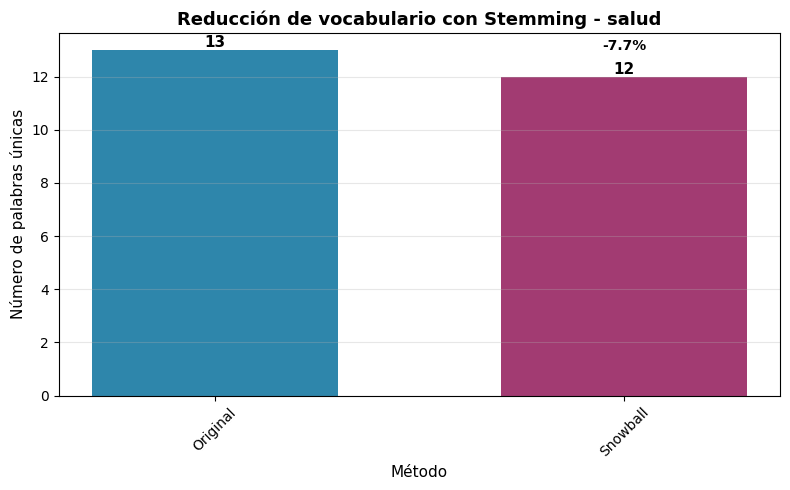

In [180]:
for item in dic_result:
    nlp_cleaning_spanish.graficar_stemming(item['Stemming'], f"Reducción de vocabulario con Stemming - {item['Documento']}")


In [191]:
print("="*10,"lematizacion","="*50)
for index, row in df_noticias_esp.iterrows():
    text = nlp_cleaning_spanish.preprocesar(row['texto'])
    print("="*10,f"{row['categoria']}","="*50)
    print(f"Original: {nlp_cleaning_spanish.Tokenizar_Palabras_NLTK(text)}")
    print(f"Lematizacion: {nlp_cleaning_spanish.lematizacion(text)}")

    print()

========== lematizacion ==================================================
========== tecnología ==================================================
Original: ['apple', 'presento', 'su', 'nuevo', 'chip', 'con', 'ia', 'integrada', 'la', 'presentacion', 'fue', 'en', 'wwdc']
Lematizacion: ['apple', 'presento', 'su', 'nuevo', 'chip', 'con', 'ia', 'integrado', 'el', 'presentacion', 'ser', 'en', 'wwdc']

========== tecnología ==================================================
Original: ['google', 'lanzo', 'gemini', 'ultra', 'su', 'modelo', 'mas', 'poderoso', 'supera', 'a', 'en', 'benchmarks']
Lematizacion: ['google', 'lanzo', 'gemini', 'ultra', 'su', 'modelo', 'mas', 'poderoso', 'superar', 'a', 'en', 'benchmark']

========== tecnología ==================================================
Original: ['openai', 'anuncio', 'con', 'capacidades', 'multimodales', 'avanzadas']
Lematizacion: ['openai', 'anuncio', 'con', 'capacidad', 'multimodal', 'avanzado']

========== economía ========================

========== Stopwords ==================================================
Sin stopwords: [('inversion', 1), ('lanzo', 1), ('supera', 1), ('farmacias', 1), ('fortalece', 1), ('dolar', 1), ('mit', 1), ('confirmo', 1), ('chip', 1), ('casos', 1), ('nuevo', 1), ('junio', 1), ('benchmarks', 1), ('modelo', 1), ('dinosaurio', 1), ('cancer', 1), ('integrada', 1), ('solido', 1), ('ano', 1), ('investigadores', 1), ('extranjera', 1), ('clinicos', 1), ('luna', 1), ('argentina', 1), ('mexicano', 1), ('anuncio', 1), ('inflacion', 1), ('oms', 1), ('inegi', 1), ('carga', 1), ('especie', 1), ('presencia', 1), ('crecio', 1), ('peso', 1), ('segun', 1), ('apple', 1), ('sur', 1), ('presentacion', 1), ('poderoso', 1), ('disponible', 1), ('cientificos', 1), ('latinoamerica', 1), ('tratamiento', 1), ('agua', 1), ('vacuna', 1), ('dengue', 1), ('directa', 1), ('bateria', 1), ('resistencia', 1), ('presento', 1), ('primer', 1), ('usd', 1), ('mercados', 1), ('multimodales', 1), ('internacionales', 1), ('mediante', 1)

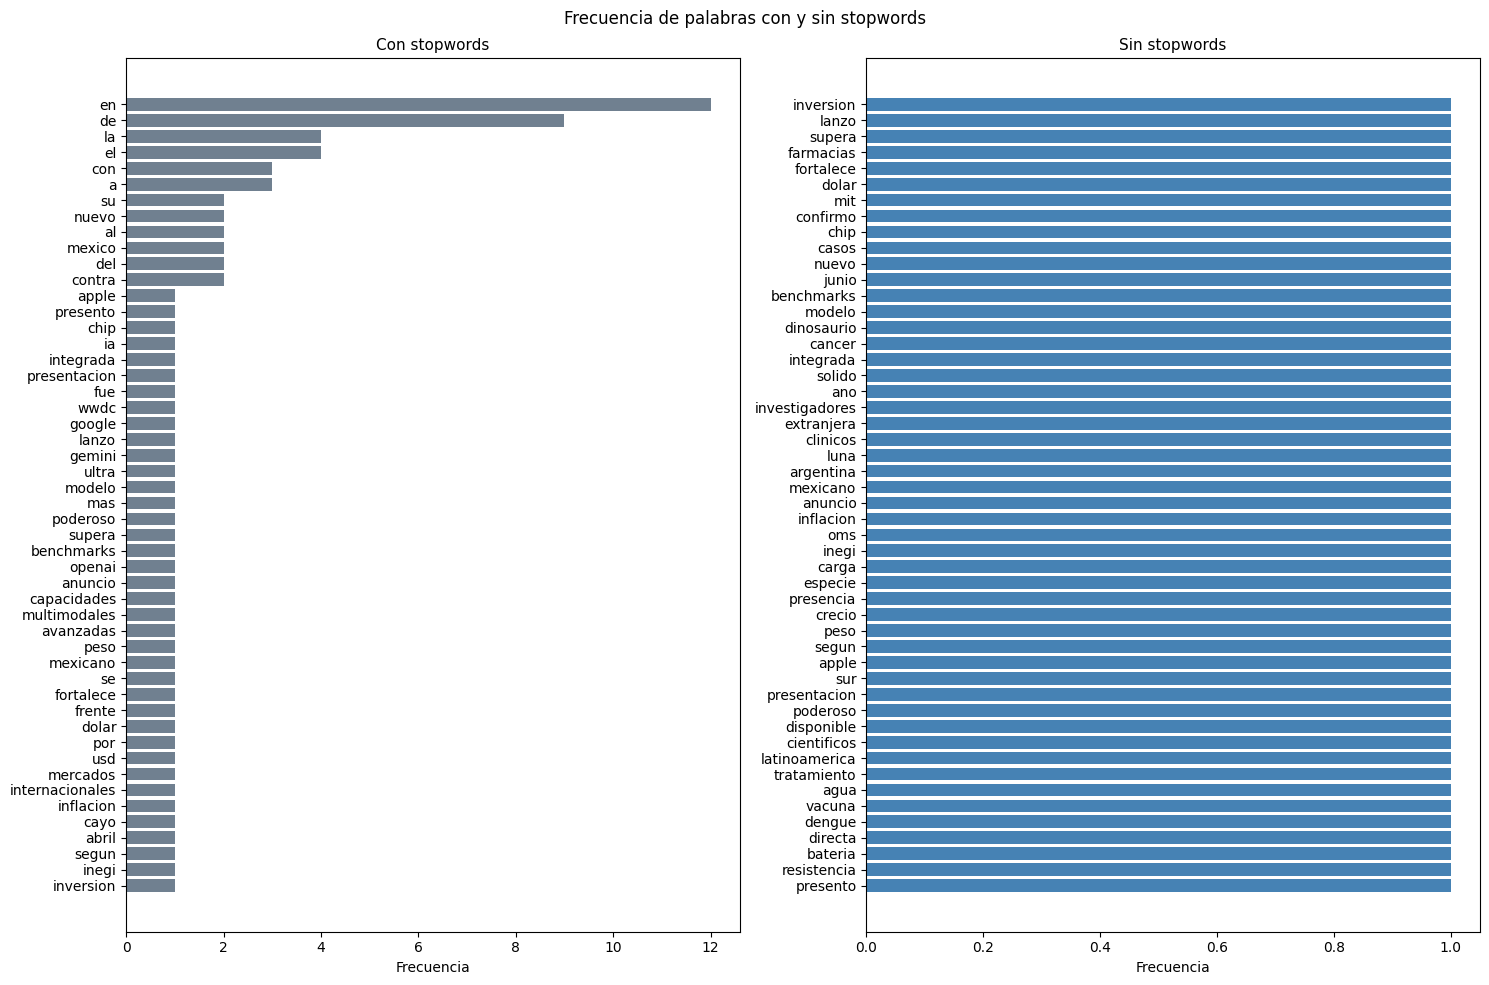

In [194]:
print("="*10,"Stopwords","="*50)
texto = ""
for index, row in df_noticias_esp.iterrows():
    texto+= row['texto'] + " "

textoProcesado = nlp_cleaning_spanish.preprocesar(texto)
sin_stopwords = nlp_cleaning_spanish.remover_stopwordsM(textoProcesado)
con_stopwords = nlp_cleaning_spanish.Tokenizar_Palabras_NLTK(textoProcesado)
sin_stopwords_freq = Counter(sin_stopwords).most_common()
con_stopwords_freq = Counter(con_stopwords).most_common()
print(f"Sin stopwords: {sin_stopwords_freq}")
print(f"Con stopwords: {con_stopwords_freq}")

nlp_cleaning_spanish.graficar_frecuencia( con_stopwords,sin_stopwords, "Frecuencia de palabras con y sin stopwords",50)